In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')

In [41]:
# 載入鳶尾花資料集
iris = load_iris()
X = iris.data
y = iris.target

# 分割訓練集和測試集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

# 建立管道器
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=2)),
    ('knn', KNeighborsClassifier())
])

# 訓練模型
pipeline.fit(X_train, y_train)

# 預測測試集
y_pred = pipeline.predict(X_test)

# 評估模型性能
accuracy = pipeline.score(X_test, y_test)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)


請用鳶尾花資料集，並用全部的欄位和資料來做預測。 請用管道器，資料要進行標準化、主成分分析（n_components=2）和 K 最近鄰預測正確率、混亂矩陣及綜合報告。

In [46]:
print(f'Accuracy: {accuracy}')
print('Confusion Matrix:')
print(conf_matrix)
print('Classification Report:')
print(class_report)

Accuracy: 0.94
Confusion Matrix:
[[19  0  0]
 [ 0 14  1]
 [ 0  2 14]]
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       0.88      0.93      0.90        15
           2       0.93      0.88      0.90        16

    accuracy                           0.94        50
   macro avg       0.94      0.94      0.94        50
weighted avg       0.94      0.94      0.94        50



承第 1 題的資料，我們要做的是鄰居數目 n_neighbors 選擇的實驗，其範圍為1 到 101，間距為 10，用(range(1,101,10))，請分別用訓練集和測試集資料，計算其整體正確率及繪圖，並解釋其結果。

In [55]:
neighbors_range = range(1, 101, 10)

train_accuracy = []
test_accuracy = []

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier())
])

# 計算不同鄰居數目下的正確率
for n_neighbors in neighbors_range:
    pipeline.set_params(knn__n_neighbors=n_neighbors)
    pipeline.fit(X_train, y_train)

    # 計算訓練集和測試集的準確率
    train_accuracy.append(pipeline.score(X_train, y_train))
    test_accuracy.append(pipeline.score(X_test, y_test))

    print(f'Number of neighbors: {n_neighbors}, Test Accuracy: {pipeline.score(X_test, y_test)}')

# 繪製圖表


Number of neighbors: 1, Test Accuracy: 0.96
Number of neighbors: 11, Test Accuracy: 0.98
Number of neighbors: 21, Test Accuracy: 0.98
Number of neighbors: 31, Test Accuracy: 0.88
Number of neighbors: 41, Test Accuracy: 0.84
Number of neighbors: 51, Test Accuracy: 0.86
Number of neighbors: 61, Test Accuracy: 0.8
Number of neighbors: 71, Test Accuracy: 0.44
Number of neighbors: 81, Test Accuracy: 0.36
Number of neighbors: 91, Test Accuracy: 0.3


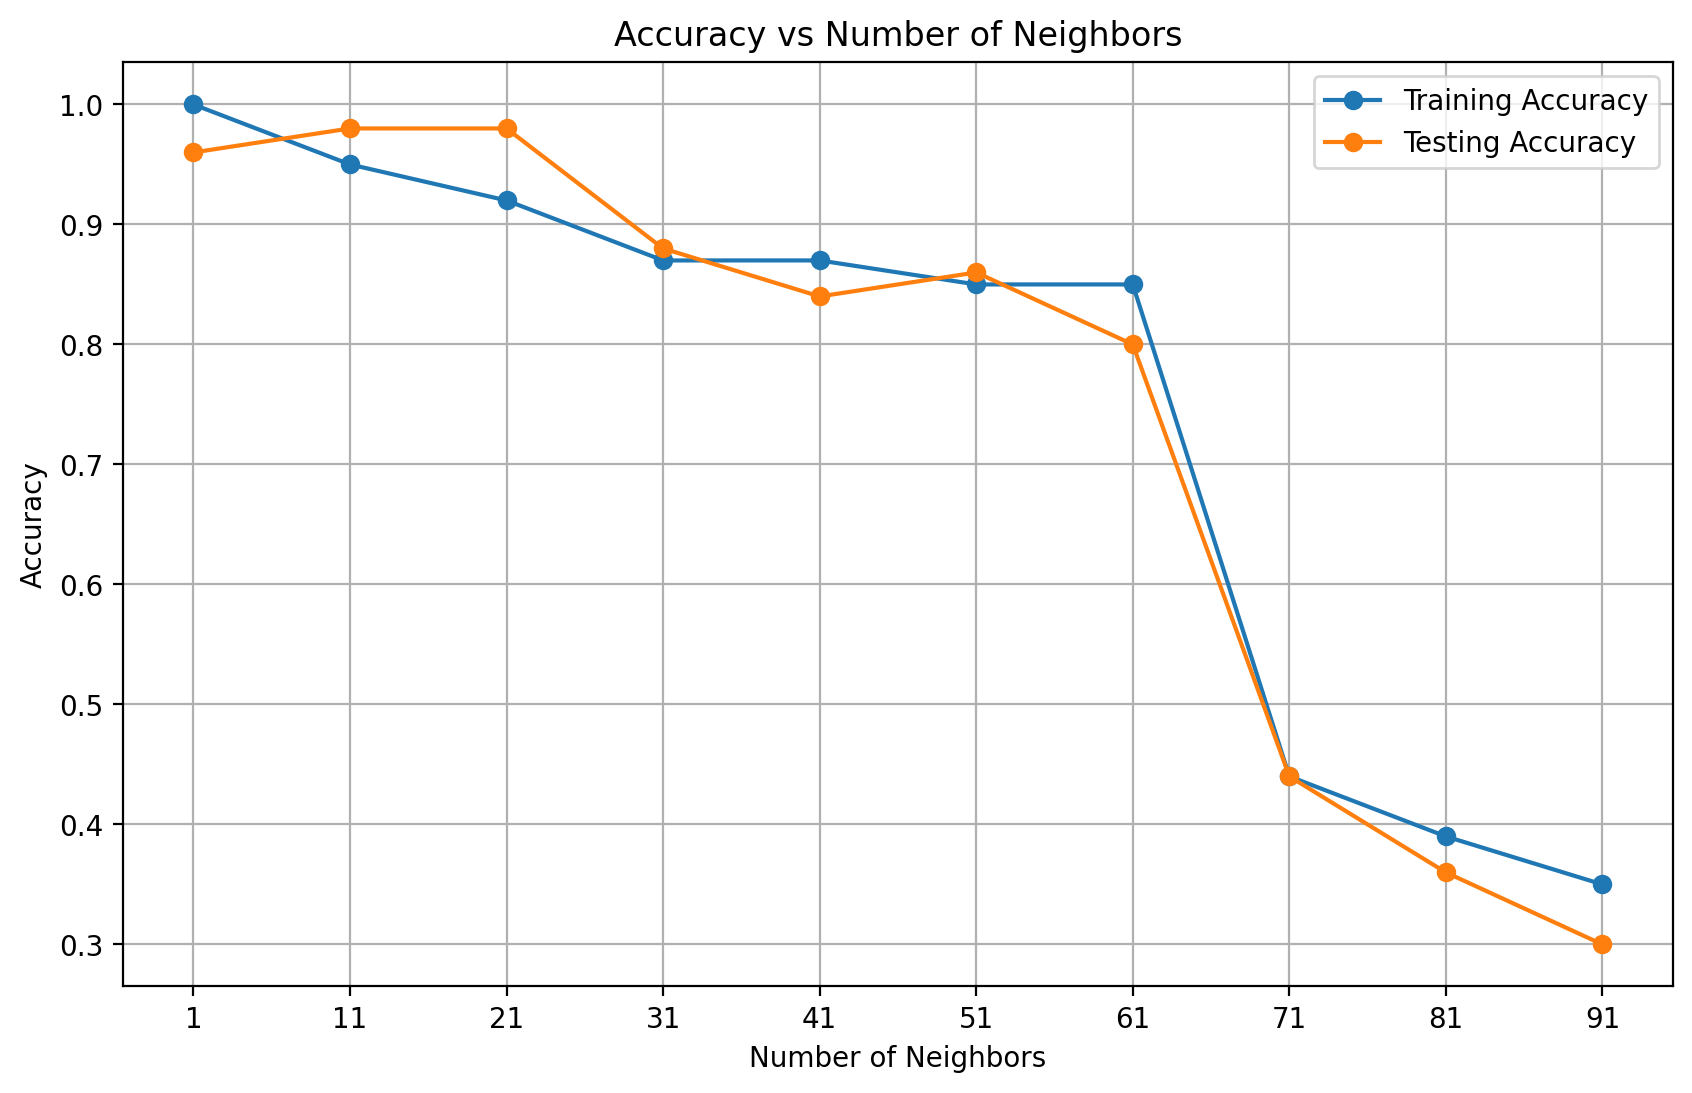

Overall Test Accuracy with 11 neighbors: 0.98


In [56]:
plt.figure(figsize=(10, 6))
plt.plot(neighbors_range, train_accuracy, marker='o', label='Training Accuracy')
plt.plot(neighbors_range, test_accuracy, marker='o', label='Testing Accuracy')
plt.title('Accuracy vs Number of Neighbors')
plt.xlabel('Number of Neighbors')
plt.ylabel('Accuracy')
plt.xticks(neighbors_range)
plt.legend()
plt.grid(True)
plt.show()

best_n_neighbors = neighbors_range[np.argmax(test_accuracy)]
pipeline.set_params(knn__n_neighbors=best_n_neighbors)
pipeline.fit(X_train, y_train)
overall_test_accuracy = pipeline.score(X_test, y_test)
print(f'Overall Test Accuracy with {best_n_neighbors} neighbors: {overall_test_accuracy}')

KNN演算法中，如果K值取很小，會使Training的準確率幾乎為1，但是Testing不一定會最優，如圖K=1時。

而K值太大則會造成模型測試不準確，無論在Training或Testing都會有很差的結果，如圖K=71, 81和91時。

總結來說，K值不適合取過大或過小，以此題為例，K=11時，Test Accurancy會最優。